# Can Linear Regression Learn Nonlinear Behavior?

**Author:** Parham Moezifar
**Date:** 2026  

## Overview
Linear regression fits a straight line to data. But what happens when the data is curved, wavy, or complex?
In this notebook, we explore how polynomial regression (an extension of linear regression) can approximate nonlinear patterns, and where it starts to fail.

## What we test:
1. Simple quadratic curve (x^2)
2. Sine wave with noise
3. Mixed polynomial + sine
4. Highly oscillatory decay function
5. Overfitting,when high degree destroys generalization

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 2.5
x=np.linspace(-5,5,100)
X=x.reshape(-1,1)

## 1: Can it learn a simple curve (x^2)?
We start simple.
The true function is a parabola. 
We add a little noise to simulate real-world data, then fit both a straight line and a degree-2 polynomial.

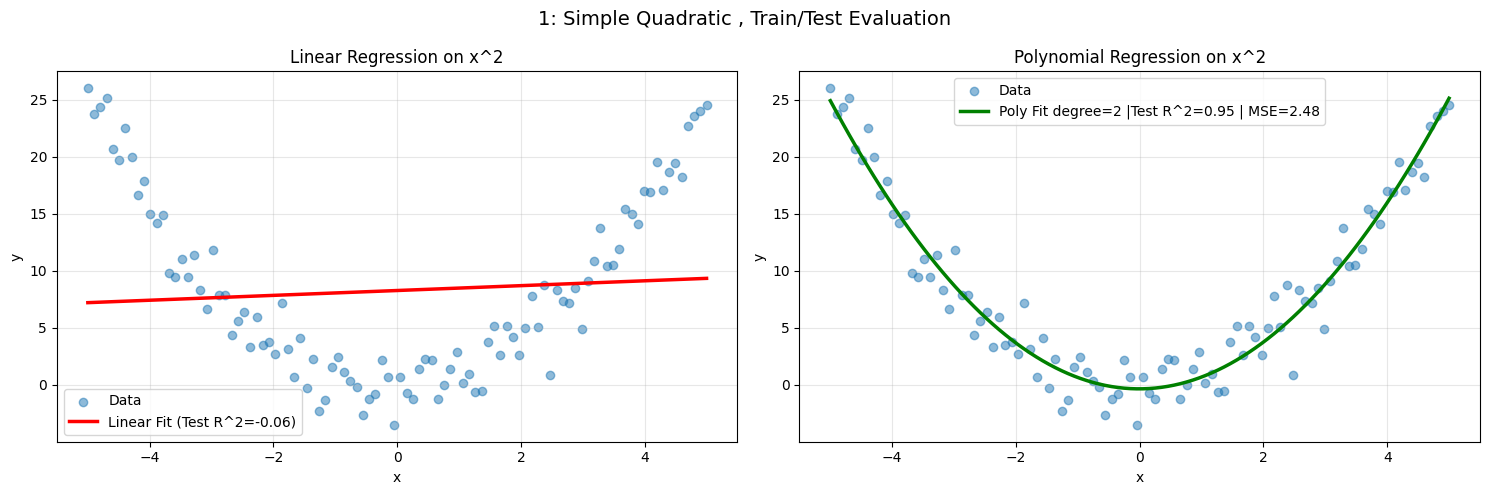

In [23]:
np.random.seed(42)
noise = np.random.normal(0,2,100)
y=x**2+noise
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
fig, axes = plt.subplots(1, 2)
model=LinearRegression()
model.fit(X_train,y_train)
prediction=model.predict(X_test)
r2=r2_score(y_test,prediction)
axes[0].scatter(x,y,alpha=0.5,label="Data")
axes[0].plot(x,model.predict(X),color="red",label=f'Linear Fit (Test R^2={r2:.2f})')
axes[0].set_title('Linear Regression on x^2')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
model.fit(X_train_poly,y_train)
prediction=model.predict(X_test_poly)
r2 = r2_score(y_test, prediction)
mse=mean_squared_error(y_test,prediction)
axes[1].scatter(x, y, alpha=0.5, label='Data')
axes[1].plot(x, model.predict(poly.transform(X)), color='green', label=f'Poly Fit degree=2 |Test R^2={r2:.2f} | MSE={mse:.2f}')
axes[1].set_title('Polynomial Regression on x^2')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()
plt.suptitle('1: Simple Quadratic , Train/Test Evaluation', fontsize=14)
plt.tight_layout()
plt.show()


## 2: Can it learn a sine wave?
A sine wave is smooth but nonlinear. We test how well polynomial regression approximates it
as we increase the degree. We also watch for **overfitting** , when the model memorizes noise instead of learning the pattern.

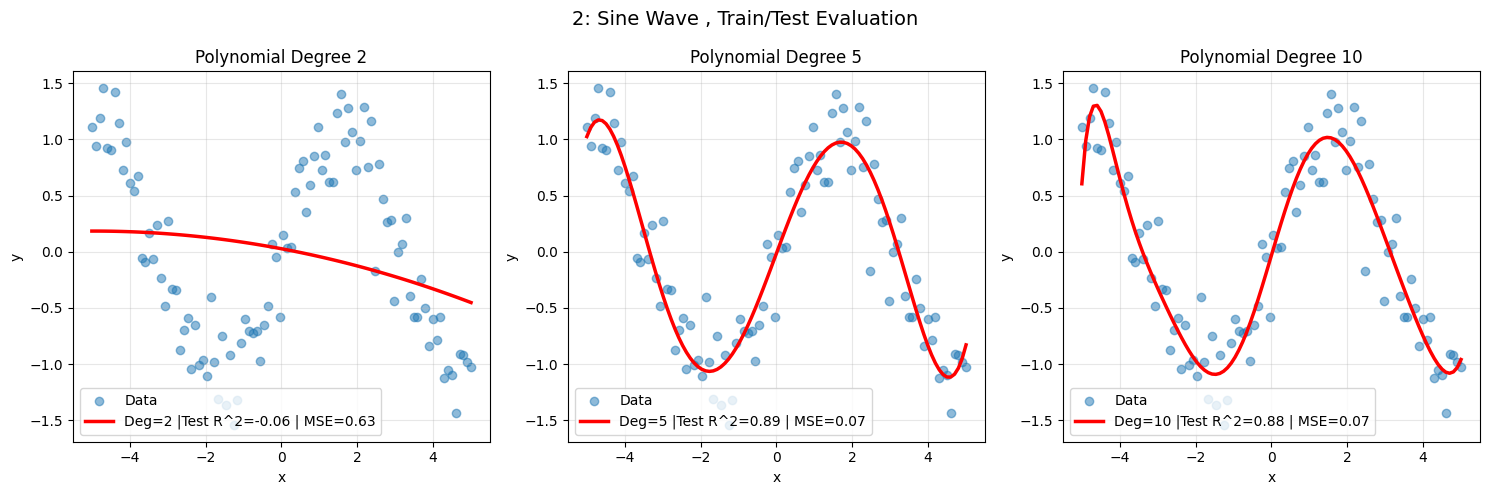

In [24]:
np.random.seed(42)
noise=np.random.normal(0,0.3,100)
y=np.sin(x)+noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sort=np.argsort(x)
fig, axes = plt.subplots(1, 3)
degrees = [2, 5, 10]
for i,deg in enumerate(degrees):    
    poly=PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly,y_train)
    test_pre=model.predict(X_test_poly)
    r2=r2_score(y_test, test_pre)
    mse=mean_squared_error(y_test,test_pre)
    prediction=model.predict(poly.transform(X))
    axes[i].scatter(x, y, alpha=0.5, label='Data')
    axes[i].plot(x[sort], prediction[sort], color='red',label=f'Deg={deg} |Test R^2={r2:.2f} | MSE={mse:.2f}')
    axes[i].set_title(f'Polynomial Degree {deg}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend()
plt.suptitle('2: Sine Wave , Train/Test Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

## 3: Mixed Function (polynomial + sine)
Now we make it harder. The true function is a combination of a sine wave AND a quadratic curve.
This is closer to real-world data .

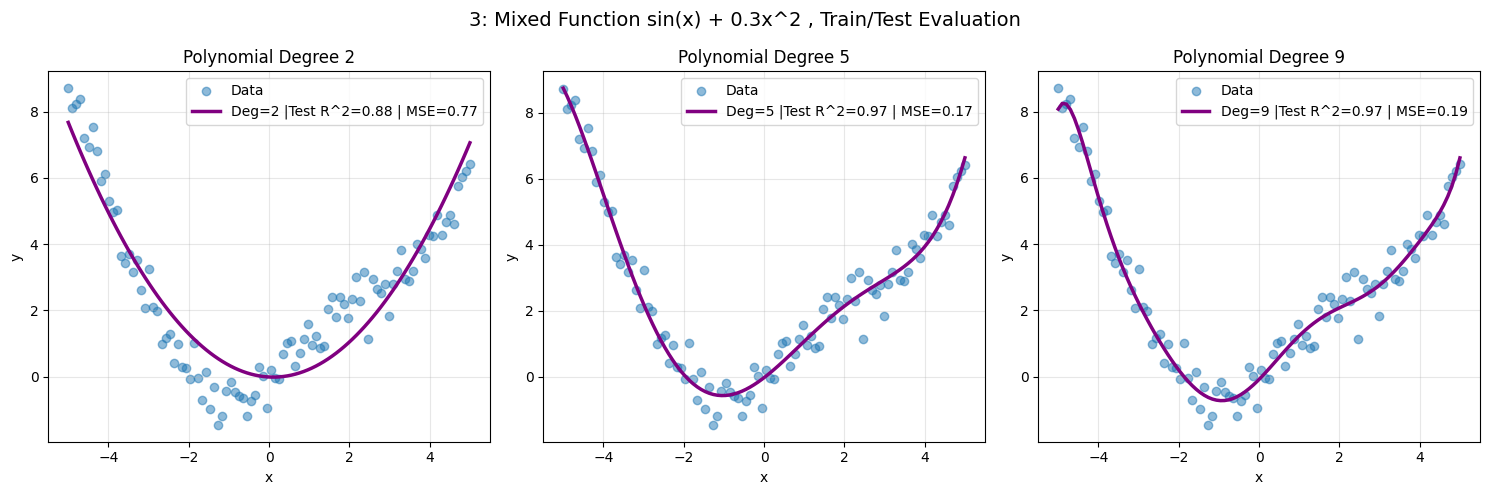

In [25]:
np.random.seed(42)
noise=np.random.normal(0,0.5,100)
y=np.sin(x)+(0.3*(x**2))+noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sort = np.argsort(x)
fig, axes = plt.subplots(1, 3)
degrees = [2, 5, 9]
for i, deg in enumerate(degrees):
    poly=PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    test_pre=model.predict(X_test_poly)
    r2=r2_score(y_test, test_pre)
    mse=mean_squared_error(y_test,test_pre)
    prediction=model.predict(poly.transform(X))
    axes[i].scatter(x, y, alpha=0.5, label='Data')
    axes[i].plot(x[sort], prediction[sort], color='purple',label=f'Deg={deg} |Test R^2={r2:.2f} | MSE={mse:.2f}')
    axes[i].set_title(f'Polynomial Degree {deg}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend()
plt.suptitle('3: Mixed Function sin(x) + 0.3x^2 , Train/Test Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

## 4: Highly Oscillatory Decay , Where Polynomial Regression Struggles
The hardest test. The function oscillates rapidly AND decays exponentially.
Even with a high degree polynomial, the model should struggle and that's the point.
This shows the **limits** of polynomial regression.

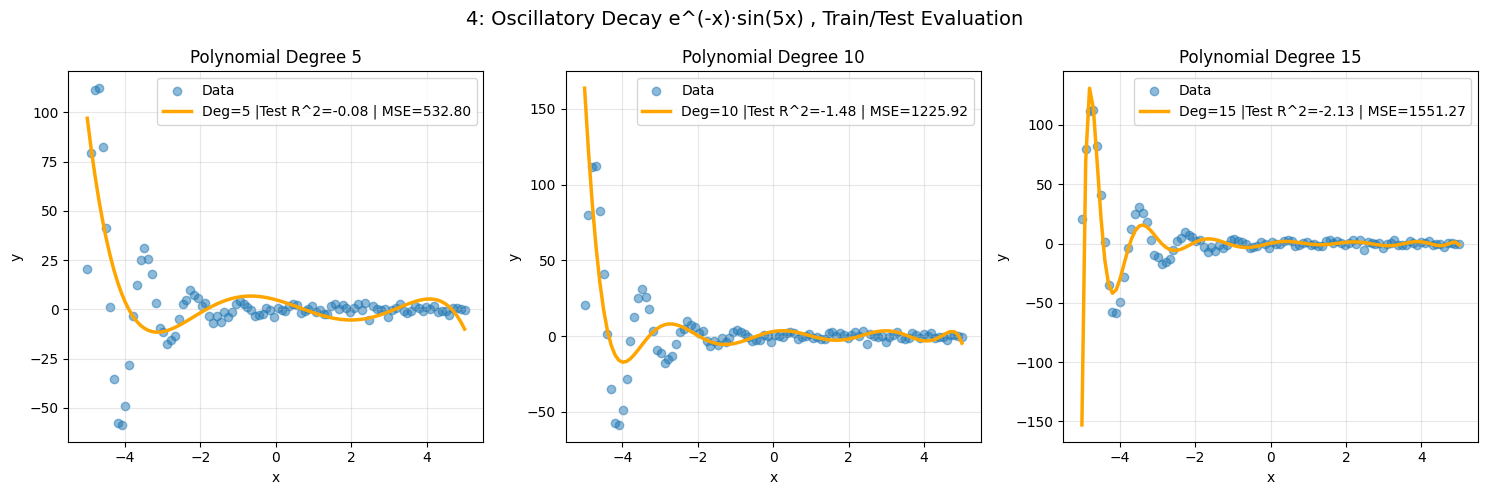

In [26]:
np.random.seed(42)
noise=np.random.normal(0,2,100)
y = np.exp(-x) * np.sin(5*x)+noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sort = np.argsort(x)
fig, axes=plt.subplots(1,3)
degree=[5,10,15]
for i,deg in enumerate(degree):
    poly=PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model=LinearRegression()
    model.fit(X_train_poly, y_train)
    test_pre = model.predict(X_test_poly)
    r2=r2_score(y_test,test_pre)
    mse = mean_squared_error(y_test, test_pre)
    prediction = model.predict(poly.transform(X))
    axes[i].scatter(x, y, alpha=0.5, label='Data')
    axes[i].plot(x[sort], prediction[sort], color='orange',label=f'Deg={deg} |Test R^2={r2:.2f} | MSE={mse:.2f}')
    axes[i].set_title(f'Polynomial Degree {deg}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend()
plt.suptitle('4: Oscillatory Decay e^(-x)·sin(5x) , Train/Test Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

## 5: Overfitting , When the Model Goes Crazy
What happens when we push the polynomial degree too high?
The model stops learning the pattern and starts memorizing the noise.
This is called **overfitting**  one of the most important concepts in all of machine learning.

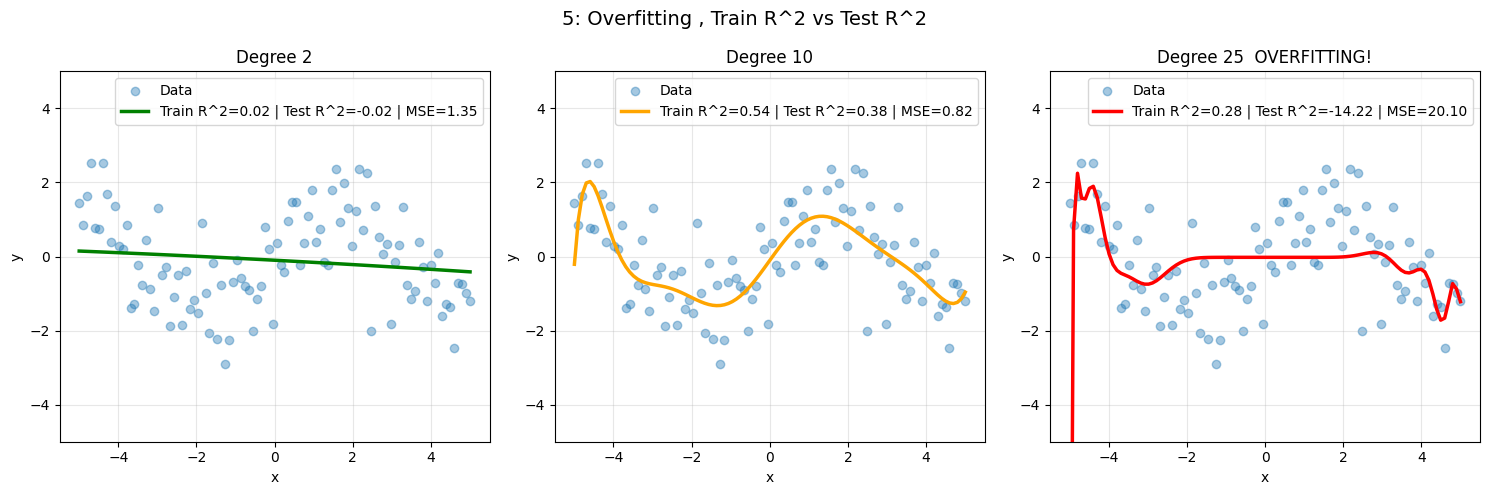

Overfitting Evidence:
Degree     Train R^2    Test R^2     MSE          Status
-----------------------------------------------------------------
2          0.0167       -0.0211      1.3481        OK
5          0.5067       0.5048       0.6538        OK
10         0.5379       0.3804       0.8181        OK
15         0.5588       0.3452       0.8645       OVERFIT
25         0.2810       -14.2246     20.1010      OVERFIT


In [27]:
np.random.seed(42)
noise =np.random.normal(0, 1, 100)
y= np.sin(x) + noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sort = np.argsort(x)
fig, axes = plt.subplots(1, 3)
degrees = [2, 10, 25]
colors = ['green', 'orange', 'red']
for i, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    r2_test  = r2_score(y_test,  model.predict(X_test_poly))
    r2_train = r2_score(y_train, model.predict(X_train_poly))
    mse = mean_squared_error(y_test, model.predict(X_test_poly))
    prediction = model.predict(poly.transform(X))
    axes[i].scatter(x, y, alpha=0.4, label='Data')
    axes[i].plot(x[sort], prediction[sort], color=colors[i],label=f'Train R^2={r2_train:.2f} | Test R^2={r2_test:.2f} | MSE={mse:.2f}')
    axes[i].set_ylim(-5, 5)
    axes[i].set_title(f'Degree {deg}{"  OVERFITTING!" if deg==25 else ""}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend()
plt.suptitle('5: Overfitting , Train R^2 vs Test R^2', fontsize=14)
plt.tight_layout()
plt.show()
print("Overfitting Evidence:")
print(f"{'Degree':<10} {'Train R^2':<12} {'Test R^2':<12} {'MSE':<12} {'Status'}")
print("-" * 65)
for deg in [2, 5, 10, 15, 25]:
    poly = PolynomialFeatures(degree=deg)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_train), y_train)
    r2_tr = r2_score(y_train, model.predict(poly.transform(X_train)))
    r2_te = r2_score(y_test,  model.predict(poly.transform(X_test)))
    mse   = mean_squared_error(y_test, model.predict(poly.transform(X_test)))
    flag  = "OVERFIT" if (r2_tr - r2_te) > 0.2 else " OK"
    print(f"{deg:<10} {r2_tr:<12.4f} {r2_te:<12.4f} {mse:<12.4f} {flag}")

## Summary & Findings

| # | Function | Best Degree | Test R² | MSE   | Verdict |
|---|----------|------------|---------|-------|---------|
| 1 | Quadratic — x² | 2          | 0.95    | 2.48  | Perfect fit |
| 2 | Sine wave — sin(x) | 5          | 0.89    | 0.07  | Good fit |
| 3 | Mixed — sin(x) + 0.3x² | 5          | 0.97    | 0.17  | Excellent fit |
| 4 | Oscillatory decay |  —          | -0.08   | 532.8 | Complete failure |
| 5 | Overfitting demo | —          | -14.22  | 20.10 | Complete breakdown |

## Conclusion

Polynomial regression dramatically increases the expressive power of linear regression
through feature engineering , transforming a line into a curve without changing the
underlying algorithm.

However, this power comes with risk. As polynomial degree increases, the model fits
training data more precisely but becomes fragile on unseen data , a phenomenon known
as **overfitting**. The experiments in this notebook demonstrate that the optimal degree
depends heavily on the complexity and noise level of the underlying function.

The key insight is that **model complexity must match data complexity** , not exceed it.
This principle extends far beyond polynomial regression and sits at the heart of
all machine learning model selection.